# Exploratory Data Analysis — TEC SG 2 - Grupo Nama (Interno)

## Contexto del negocio
Dataset de **cadena de restaurantes de comida japonesa** con **5 sucursales** y un corporativo.
Contiene datos transaccionales de costos y márgenes para **Q1 2026 (enero–marzo)**.

| Código | Nombre completo |
|--------|----------------|
| ANT | Antea |
| SOK | Soke |
| JUR | Jur |
| MOR | Mor |
| CAM | Cam |

## Fuentes de datos
| Fuente | Descripción | Meses |
|--------|------------|-------|
| **TEC SG 2 - BD 2026.csv** | Base transaccional (ventas por producto) | Enero–Marzo 2026 |
| **TEC SG - GN (Interno).xlsx** | GASTOS 2026, NÓMINA 2026 | Solo Enero 2026 |

> **Nota:** Los análisis de gastos operativos y nómina (secciones 4–6) cubren únicamente enero 2026
> por limitación de la fuente xlsx. El análisis transaccional (secciones 2–3, 7–8) cubre Q1 completo.

## Pipeline del análisis
1. **Carga y limpieza** — CSV para BD, xlsx para gastos/nómina
2. **Análisis de ingresos** — Revenue por sucursal, categoría y producto (Q1 2026)
3. **Análisis de costos y márgenes** — Estructura de costos, utilidad bruta, productos con margen negativo
4. **Análisis temporal** — Tendencias mes a mes (enero–marzo 2026)
5. **Análisis de gastos operativos** — Distribución por categoría y sucursal (enero)
6. **Análisis de nómina** — Costo laboral por sucursal (enero)
7. **Estado de resultados simplificado** — Visión integrada de rentabilidad (enero)
8. **Distribución de precios y volúmenes**
9. **Análisis de categoría de menú**

---
## 1. Carga de datos y limpieza

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

CSV_FILE = 'TEC SG 2 - Grupo Nama (Interno) - BD 2026.csv'
XLSX_FILE = 'TEC SG - GN (Interno).xlsx'

# --- BD 2026: Base transaccional Q1 2026 (CSV) ---
bd_raw = pd.read_csv(CSV_FILE, dtype=str)

# Convertir columnas numéricas (CSV viene con formato "$X,XXX.XX")
_num_cols = ['CANTIDAD', 'SUBTOTAL', 'TOTAL', 'COSTO TOTAL SIN IVA',
             'COSTO TOTAL DEL SERVICIO', 'UTILIDAD BRUTA', 'MARGEN BRUTO']
for col in _num_cols:
    bd_raw[col] = pd.to_numeric(
        bd_raw[col].str.replace(r'[$,]', '', regex=True).str.strip(),
        errors='coerce'
    )
# Costos individuales 1–50
for i in range(1, 51):
    c = f'COSTO {i}'
    if c in bd_raw.columns:
        bd_raw[c] = pd.to_numeric(
            bd_raw[c].str.replace(r'[$,]', '', regex=True).str.strip(),
            errors='coerce'
        )

# --- GASTOS 2026: Gastos operativos (xlsx - solo enero) ---
gastos_raw = pd.read_excel(XLSX_FILE, sheet_name='GASTOS 2026')

# --- NÓMINA 2026 (xlsx - solo enero) ---
nomina_raw = pd.read_excel(XLSX_FILE, sheet_name='NÓMINA 2026')

# --- Glosario ---
glosario = pd.read_excel(XLSX_FILE, sheet_name='Glosario ER')

print(f"BD 2026 (CSV):   {bd_raw.shape}  —  meses: {sorted(bd_raw['MES'].unique())}")
print(f"GASTOS 2026:     {gastos_raw.shape}")
print(f"NÓMINA 2026:     {nomina_raw.shape}")
print(f"Glosario:        {glosario.shape}")

BD 2026 (CSV):   (8102, 68)  —  meses: ['ENERO 2026', 'FEBRERO 2026', 'MARZO 2026']
GASTOS 2026:     (999, 7)
NÓMINA 2026:     (999, 8)
Glosario:        (2673, 10)


In [6]:
# Eliminar columnas completamente vacías o irrelevantes
drop_cols = ['FECHA VENTA', 'COL ESPECIAL 4', 'COL ESPECIAL 5', 'COL ESPECIAL 6',
             'COL ESPECIAL 2', 'COL ESPECIAL 3']
bd = bd_raw.drop(columns=[c for c in drop_cols if c in bd_raw.columns]).copy()

# Renombrar columnas para claridad
bd = bd.rename(columns={
    'COL ESPECIAL 1': 'CATEGORÍA MENÚ',
    'LÍNEA DE NEGOCIO': 'SUCURSAL',
})

# Variables derivadas
bd['PRECIO_UNITARIO'] = np.where(bd['CANTIDAD'] > 0, bd['SUBTOTAL'] / bd['CANTIDAD'], 0)
bd['COSTO_UNITARIO']  = np.where(bd['CANTIDAD'] > 0, bd['COSTO TOTAL SIN IVA'] / bd['CANTIDAD'], 0)

# Orden de meses para visualizaciones
MES_ORDER = ['ENERO 2026', 'FEBRERO 2026', 'MARZO 2026']

print("Columnas finales BD:", bd.shape[1])
print(f"\nRegistros totales: {len(bd)}")
print(f"Meses cubiertos:   {sorted(bd['MES'].unique())}")
print(f"Sucursales:        {sorted(bd['SUCURSAL'].unique())}")
bd.head(3)

Columnas finales BD: 64

Registros totales: 8102
Meses cubiertos:   ['ENERO 2026', 'FEBRERO 2026', 'MARZO 2026']
Sucursales:        ['ANT', 'CAM', 'JUR', 'MOR', 'SOK']


,MES,SUCURSAL,SUBCATEGORÍA 1,SUBCATEGORÍA 2,CANTIDAD,SUBTOTAL,TOTAL,COSTO 1,COSTO 2,COSTO 3,...,COSTO 48,COSTO 49,COSTO 50,COSTO TOTAL SIN IVA,COSTO TOTAL DEL SERVICIO,UTILIDAD BRUTA,MARGEN BRUTO,CATEGORÍA MENÚ,PRECIO_UNITARIO,COSTO_UNITARIO
0,ENERO 2026,ANT,Alimentos,YAKIMESHI MIXTO,959,152135.84,176477.57,36783.88,NaN,NaN,...,NaN,NaN,NaN,36783.88,42669.30,115351.96,0.76,CALIENTE,158.640083,38.356496
1,ENERO 2026,ANT,Alimentos,LOBSTER ROLL,458,107989.65,125267.99,50819.88,NaN,NaN,...,NaN,NaN,NaN,50819.88,58951.06,57169.77,0.53,MAKIS,235.785262,110.960437
2,ENERO 2026,ANT,Alimentos,CRISPY TUNA,512,103055.61,119544.51,36479.93,NaN,NaN,...,NaN,NaN,NaN,36479.93,42316.72,66575.68,0.65,MAKIS,201.280488,71.249863


### 1.2 Diagnóstico: registros con margen bruto = 0

Antes de continuar, es importante entender por qué hay registros con `MARGEN BRUTO == 0`.
El diagnóstico revela que son **productos del catálogo sin ventas** (SUBTOTAL=0, CANTIDAD=0).
No aportan información al análisis de rentabilidad y deben filtrarse.

Total registros:        8102
MARGEN BRUTO == 0:      3666 (45.2%)
SUBTOTAL == 0:          3666 (45.2%)
CANTIDAD == 0:          3611 (44.6%)

De los 3666 registros con margen=0:
  - 3641 tienen SUBTOTAL=0 Y COSTO=0 (placeholders sin venta)
  - 25 tienen SUBTOTAL=0 pero COSTO>0 (cortesías/promos)
  - 0 otros

Registros con margen=0 por sucursal:
SUCURSAL
ANT     642 de 1539 (42%)
CAM     567 de 1608 (35%)
JUR     648 de 1569 (41%)
MOR    1098 de 1632 (67%)
SOK     711 de 1754 (41%)


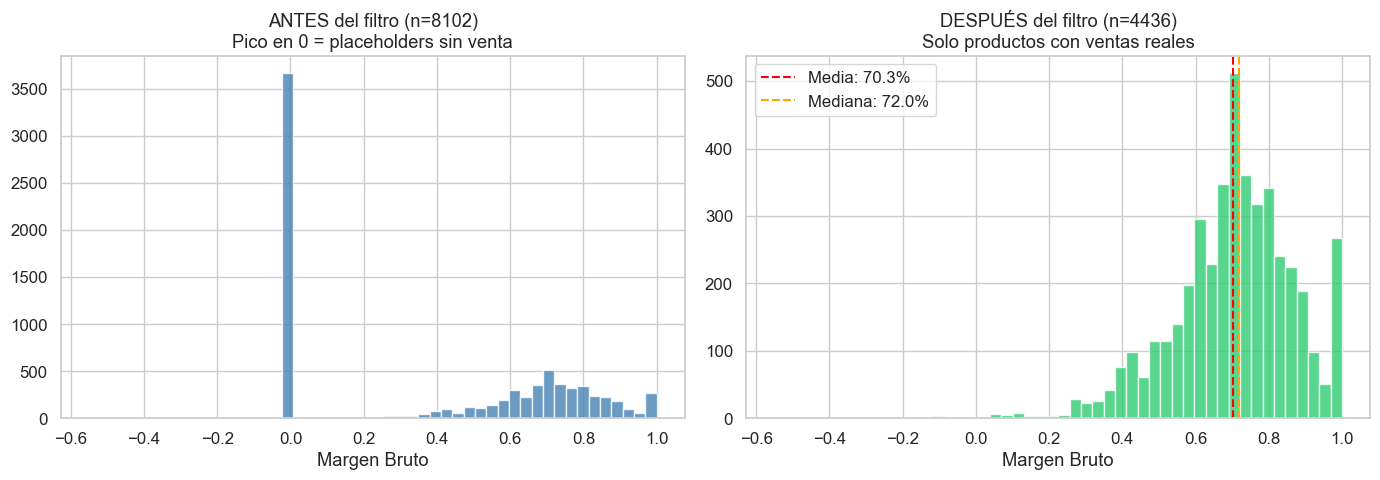

In [7]:
# --- Diagnóstico de MARGEN BRUTO == 0 ---
total = len(bd)
zero_margin = (bd['MARGEN BRUTO'] == 0).sum()
zero_subtotal = (bd['SUBTOTAL'] == 0).sum()
zero_cantidad = (bd['CANTIDAD'] == 0).sum()

print(f"Total registros:        {total}")
print(f"MARGEN BRUTO == 0:      {zero_margin} ({zero_margin/total:.1%})")
print(f"SUBTOTAL == 0:          {zero_subtotal} ({zero_subtotal/total:.1%})")
print(f"CANTIDAD == 0:          {zero_cantidad} ({zero_cantidad/total:.1%})")

m0 = bd[bd['MARGEN BRUTO'] == 0]
both_zero = ((m0['SUBTOTAL'] == 0) & (m0['COSTO TOTAL SIN IVA'] == 0)).sum()
sub_zero_cost_pos = ((m0['SUBTOTAL'] == 0) & (m0['COSTO TOTAL SIN IVA'] > 0)).sum()
print(f"\nDe los {zero_margin} registros con margen=0:")
print(f"  - {both_zero} tienen SUBTOTAL=0 Y COSTO=0 (placeholders sin venta)")
print(f"  - {sub_zero_cost_pos} tienen SUBTOTAL=0 pero COSTO>0 (cortesías/promos)")
print(f"  - {zero_margin - both_zero - sub_zero_cost_pos} otros")

print(f"\nRegistros con margen=0 por sucursal:")
print(bd.groupby('SUCURSAL')['MARGEN BRUTO'].apply(
    lambda x: f"{(x==0).sum()} de {len(x)} ({(x==0).mean():.0%})").to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(bd['MARGEN BRUTO'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'ANTES del filtro (n={total})\nPico en 0 = placeholders sin venta')
axes[0].set_xlabel('Margen Bruto')

bd_activo = bd[bd['SUBTOTAL'] > 0]
axes[1].hist(bd_activo['MARGEN BRUTO'], bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title(f'DESPUÉS del filtro (n={len(bd_activo)})\nSolo productos con ventas reales')
axes[1].set_xlabel('Margen Bruto')
axes[1].axvline(bd_activo['MARGEN BRUTO'].mean(), color='red', linestyle='--',
                label=f"Media: {bd_activo['MARGEN BRUTO'].mean():.1%}")
axes[1].axvline(bd_activo['MARGEN BRUTO'].median(), color='orange', linestyle='--',
                label=f"Mediana: {bd_activo['MARGEN BRUTO'].median():.1%}")
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
# --- FILTRO: Conservar solo productos con ventas reales ---
bd_all = bd.copy()
bd = bd[bd['SUBTOTAL'] > 0].copy()

print(f"Registros originales:         {len(bd_all)}")
print(f"Registros con venta real:     {len(bd)} ({len(bd)/len(bd_all):.1%})")
print(f"Registros filtrados (sin venta): {len(bd_all) - len(bd)}")
print(f"\nProductos únicos con venta: {bd['SUBCATEGORÍA 2'].nunique()}")
print(f"Margen bruto promedio: {bd['MARGEN BRUTO'].mean():.1%}")
print(f"Mediana margen bruto:  {bd['MARGEN BRUTO'].median():.1%}")
print(f"\nPor mes:")
print(bd.groupby('MES').agg(
    Registros=('SUBTOTAL','count'),
    Ingreso=('SUBTOTAL','sum'),
    Margen_Prom=('MARGEN BRUTO','mean')
).to_string(float_format='${:,.0f}'.format))

Registros originales:         8102
Registros con venta real:     4436 (54.8%)
Registros filtrados (sin venta): 3666

Productos únicos con venta: 1059
Margen bruto promedio: 70.3%
Mediana margen bruto:  72.0%

Por mes:
              Registros    Ingreso  Margen_Prom
MES                                            
ENERO 2026         1482 $8,986,391           $1
FEBRERO 2026       1502 $8,349,196           $1
MARZO 2026         1452 $8,844,725           $1


### 1.3 Limpieza de GASTOS y NÓMINA

**Pipeline:**
- **GASTOS**: Se filtran filas con `FECHA GASTO` no nula (258 de 999 filas útiles). Se eliminan filas sin categoría.
- **NÓMINA**: Se filtran filas con `FECHA NÓMINA` no nula (24 filas útiles). Se renombra `Unnamed: 3` → `CONCEPTO_NÓMINA`.

In [9]:
# --- GASTOS: filtrar filas válidas ---
gastos = gastos_raw[gastos_raw['FECHA GASTO'].notna()].copy()
gastos = gastos[gastos['CATEGORÍA GASTO'].notna()]
gastos = gastos.drop(columns=['TOTAL'], errors='ignore')

# Renombrar sucursales xlsx (A/B/C/D/E) → códigos 3 letras del CSV
XL_TO_CSV = {'A': 'ANT', 'B': 'SOK', 'C': 'JUR', 'D': 'MOR', 'E': 'CAM'}
gastos['SUCURSAL'] = gastos['SUCURSAL'].map(lambda x: XL_TO_CSV.get(x, x))

print(f"GASTOS después de limpieza: {gastos.shape}")
print(f"  Sucursales: {sorted(gastos['SUCURSAL'].dropna().unique())}")
print(f"  Categorías: {sorted(gastos['CATEGORÍA GASTO'].unique())}")

# --- NÓMINA: filtrar filas válidas ---
nomina = nomina_raw[nomina_raw['FECHA NÓMINA'].notna()].copy()
nomina = nomina.rename(columns={'Unnamed: 3': 'CONCEPTO_NÓMINA'})
nomina = nomina.drop(columns=['Unnamed: 4', 'CONCEPTO', 'TOTAL'], errors='ignore')
nomina['SUCURSAL'] = nomina['SUCURSAL'].map(lambda x: XL_TO_CSV.get(x, x))

print(f"\nNÓMINA después de limpieza: {nomina.shape}")
print(f"  Sucursales: {sorted(nomina['SUCURSAL'].unique())}")
print(f"  Conceptos: {sorted(nomina['CONCEPTO_NÓMINA'].unique())}")
nomina.head()

GASTOS después de limpieza: (192, 6)
  Sucursales: ['A', 'B', 'C', 'Corporativo', 'D', 'E']
  Categorías: ['Gastos Administrativos', 'Gastos Comerciales', 'Gastos Financieros', 'Gastos Operativos', 'Viáticos']

NÓMINA después de limpieza: (24, 5)
  Sucursales: ['A', 'B', 'C', 'Corporativo', 'D', 'E']
  Conceptos: ['Finiquitos', 'Imss', 'Nomina Corporativa', 'Nomina Operativa']


,MES NÓMINA,FECHA NÓMINA,SUCURSAL,CONCEPTO_NÓMINA,SUBTOTAL
0,ENERO 2026,2026-01-31,A,Nomina Operativa,362738.0517
1,ENERO 2026,2026-01-31,A,Finiquitos,0.0000
2,ENERO 2026,2026-01-31,A,Imss,122154.0500
3,ENERO 2026,2026-01-31,A,Nomina Corporativa,161467.8883
5,ENERO 2026,2026-01-31,E,Nomina Operativa,131434.1568


---
## 2. Análisis de ingresos por sucursal y categoría (Q1 2026)

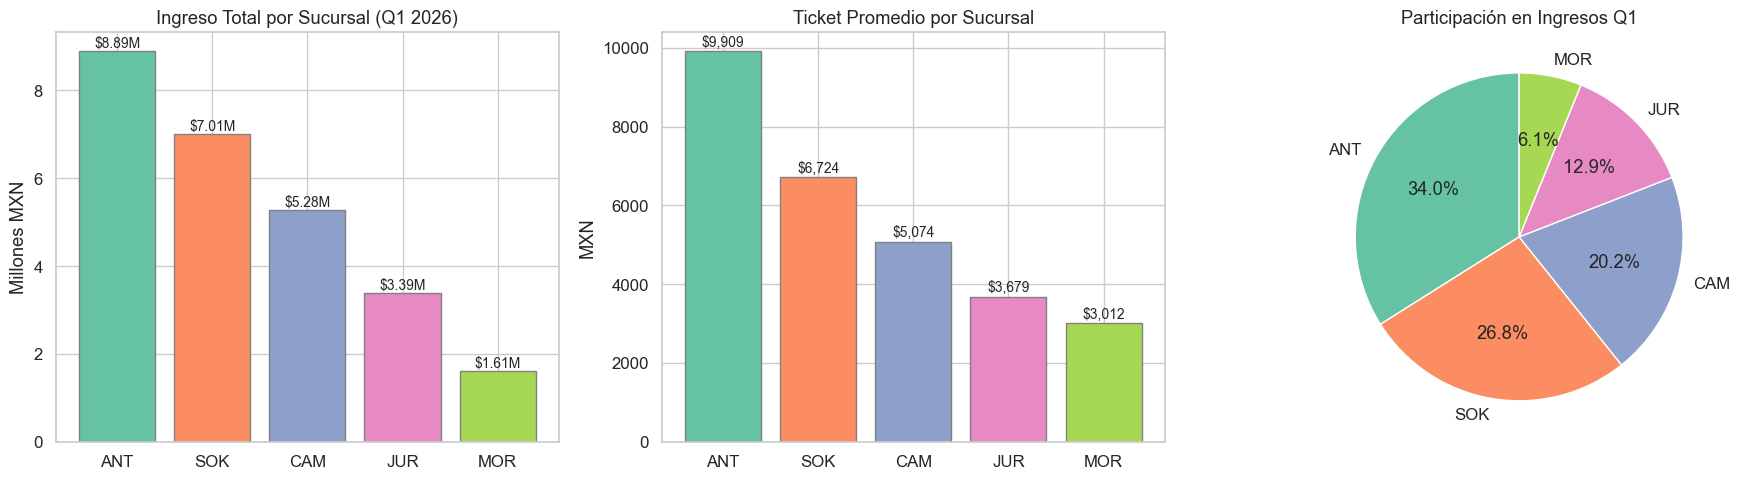

          Transacciones  Ingreso_Total  Ticket_Promedio  Cantidad_Total
SUCURSAL                                                               
ANT                 897  $8,888,449.74        $9,909.09           70220
SOK                1043  $7,012,627.43        $6,723.52           84087
CAM                1041  $5,282,287.15        $5,074.24           47162
JUR                 921  $3,388,708.40        $3,679.38           29224
MOR                 534  $1,608,237.93        $3,011.68           14317


In [10]:
# --- 2.1 Revenue por sucursal (Q1 agregado) ---
rev_suc = bd.groupby('SUCURSAL').agg(
    Transacciones=('SUBTOTAL', 'count'),
    Ingreso_Total=('SUBTOTAL', 'sum'),
    Ticket_Promedio=('SUBTOTAL', 'mean'),
    Cantidad_Total=('CANTIDAD', 'sum'),
).sort_values('Ingreso_Total', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = sns.color_palette('Set2', n_colors=5)

bars = axes[0].bar(rev_suc.index, rev_suc['Ingreso_Total'] / 1e6, color=colors, edgecolor='gray')
axes[0].set_title('Ingreso Total por Sucursal (Q1 2026)')
axes[0].set_ylabel('Millones MXN')
for bar, val in zip(bars, rev_suc['Ingreso_Total']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'${val/1e6:.2f}M', ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(rev_suc.index, rev_suc['Ticket_Promedio'], color=colors, edgecolor='gray')
axes[1].set_title('Ticket Promedio por Sucursal')
axes[1].set_ylabel('MXN')
for bar, val in zip(bars2, rev_suc['Ticket_Promedio']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10)

axes[2].pie(rev_suc['Ingreso_Total'], labels=rev_suc.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[2].set_title('Participación en Ingresos Q1')

plt.tight_layout()
plt.show()
print(rev_suc.to_string(float_format='${:,.2f}'.format))

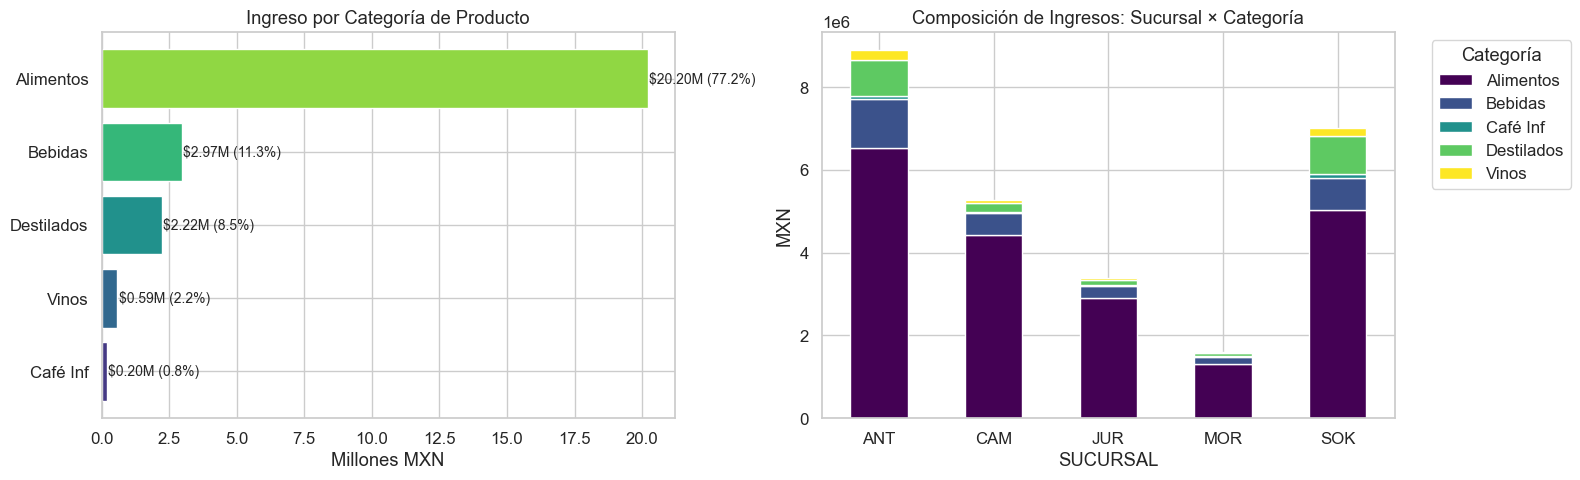

In [11]:
# --- 2.2 Revenue por categoría de producto (SUBCATEGORÍA 1) ---
rev_cat = bd.groupby('SUBCATEGORÍA 1').agg(
    Transacciones=('SUBTOTAL', 'count'),
    Ingreso_Total=('SUBTOTAL', 'sum'),
    Pct_Ingreso=('SUBTOTAL', lambda x: x.sum() / bd['SUBTOTAL'].sum() * 100),
    Cantidad_Total=('CANTIDAD', 'sum'),
).sort_values('Ingreso_Total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot horizontal
rev_cat_sorted = rev_cat.sort_values('Ingreso_Total')
axes[0].barh(rev_cat_sorted.index, rev_cat_sorted['Ingreso_Total'] / 1e6, color=sns.color_palette('viridis', 5))
axes[0].set_xlabel('Millones MXN')
axes[0].set_title('Ingreso por Categoría de Producto')
for i, (val, pct) in enumerate(zip(rev_cat_sorted['Ingreso_Total'], rev_cat_sorted['Pct_Ingreso'])):
    axes[0].text(val/1e6 + 0.05, i, f'${val/1e6:.2f}M ({pct:.1f}%)', va='center', fontsize=10)

# Stacked bar: categoría × sucursal
pivot = bd.pivot_table(values='SUBTOTAL', index='SUCURSAL', columns='SUBCATEGORÍA 1', aggfunc='sum', fill_value=0)
pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Composición de Ingresos: Sucursal × Categoría')
axes[1].set_ylabel('MXN')
axes[1].legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

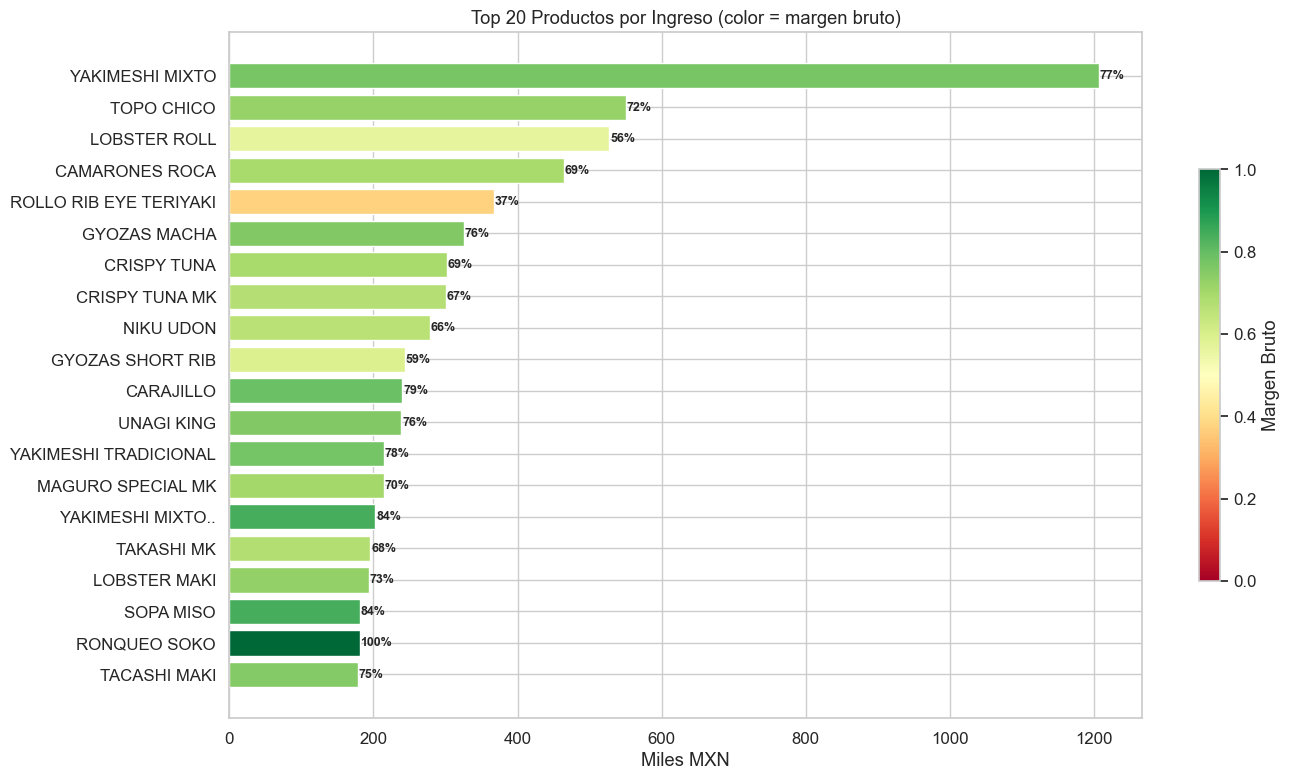

In [12]:
# --- 2.3 Top 20 productos por ingreso ---
top20 = bd.groupby('SUBCATEGORÍA 2').agg(
    Cantidad=('CANTIDAD', 'sum'),
    Ingreso=('SUBTOTAL', 'sum'),
    Margen_Prom=('MARGEN BRUTO', 'mean'),
).sort_values('Ingreso', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top20.index[::-1], top20['Ingreso'][::-1] / 1000,
               color=[plt.cm.RdYlGn(m) for m in top20['Margen_Prom'][::-1]])
ax.set_xlabel('Miles MXN')
ax.set_title('Top 20 Productos por Ingreso (color = margen bruto)')

# Añadir margen como texto
for i, (ing, marg) in enumerate(zip(top20['Ingreso'][::-1], top20['Margen_Prom'][::-1])):
    ax.text(ing/1000 + 1, i, f'{marg:.0%}', va='center', fontsize=9, fontweight='bold')

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label('Margen Bruto')

plt.tight_layout()
plt.show()

---
## 2.4 Análisis temporal: tendencias mes a mes (enero–marzo 2026)

**Justificación:** Con tres meses de datos se pueden identificar tendencias de crecimiento,
estacionalidad incipiente y cambios en la mezcla de ventas por sucursal.

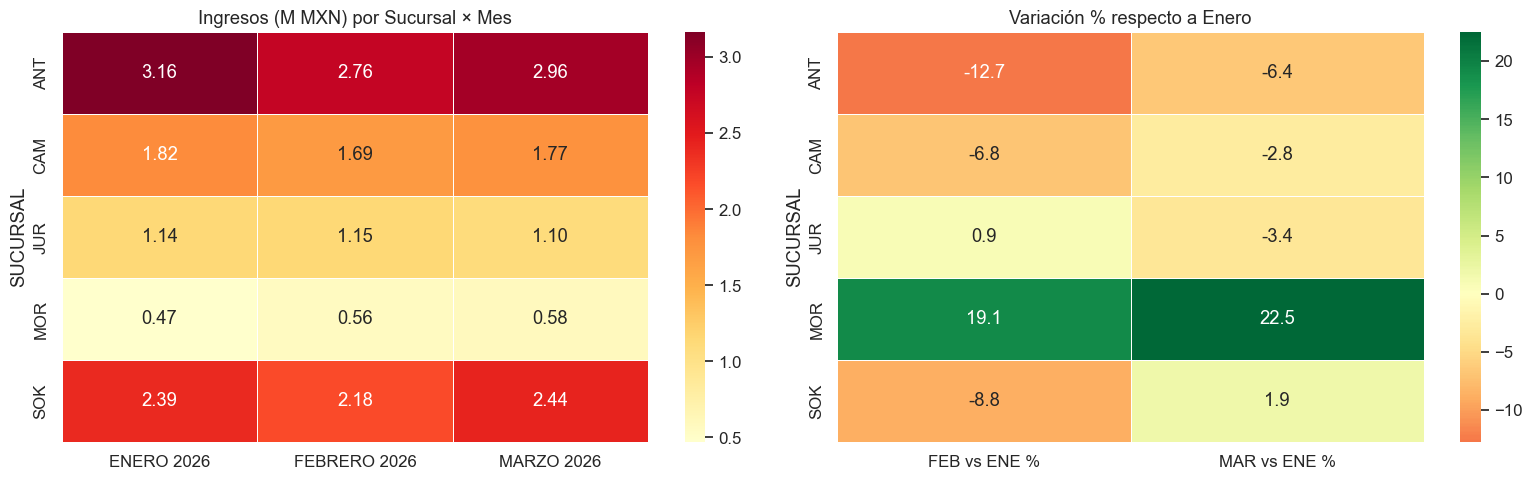


Ingresos por sucursal y mes (MXN):
MES       ENERO 2026  FEBRERO 2026  MARZO 2026
SUCURSAL                                      
ANT       $3,164,779    $2,761,987  $2,961,684
CAM       $1,819,230    $1,694,638  $1,768,420
JUR       $1,139,072    $1,149,185  $1,100,452
MOR         $470,759      $560,801    $576,678
SOK       $2,392,551    $2,182,585  $2,437,492


In [13]:
# --- 2.4.1 Heatmap de ingresos: sucursal × mes ---
pivot_mes = bd.pivot_table(values='SUBTOTAL', index='SUCURSAL', columns='MES',
                            aggfunc='sum', fill_value=0)[MES_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_mes / 1e6, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Ingresos (M MXN) por Sucursal × Mes')
axes[0].set_xlabel('')

# Crecimiento relativo (feb vs ene, mar vs ene)
pct_change = pivot_mes.copy().astype(float)
pct_change['FEB vs ENE %'] = (pivot_mes['FEBRERO 2026'] / pivot_mes['ENERO 2026'] - 1) * 100
pct_change['MAR vs ENE %'] = (pivot_mes['MARZO 2026']  / pivot_mes['ENERO 2026'] - 1) * 100

sns.heatmap(pct_change[['FEB vs ENE %','MAR vs ENE %']], annot=True, fmt='.1f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title('Variación % respecto a Enero')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print("\nIngresos por sucursal y mes (MXN):")
print(pivot_mes.to_string(float_format='${:,.0f}'.format))

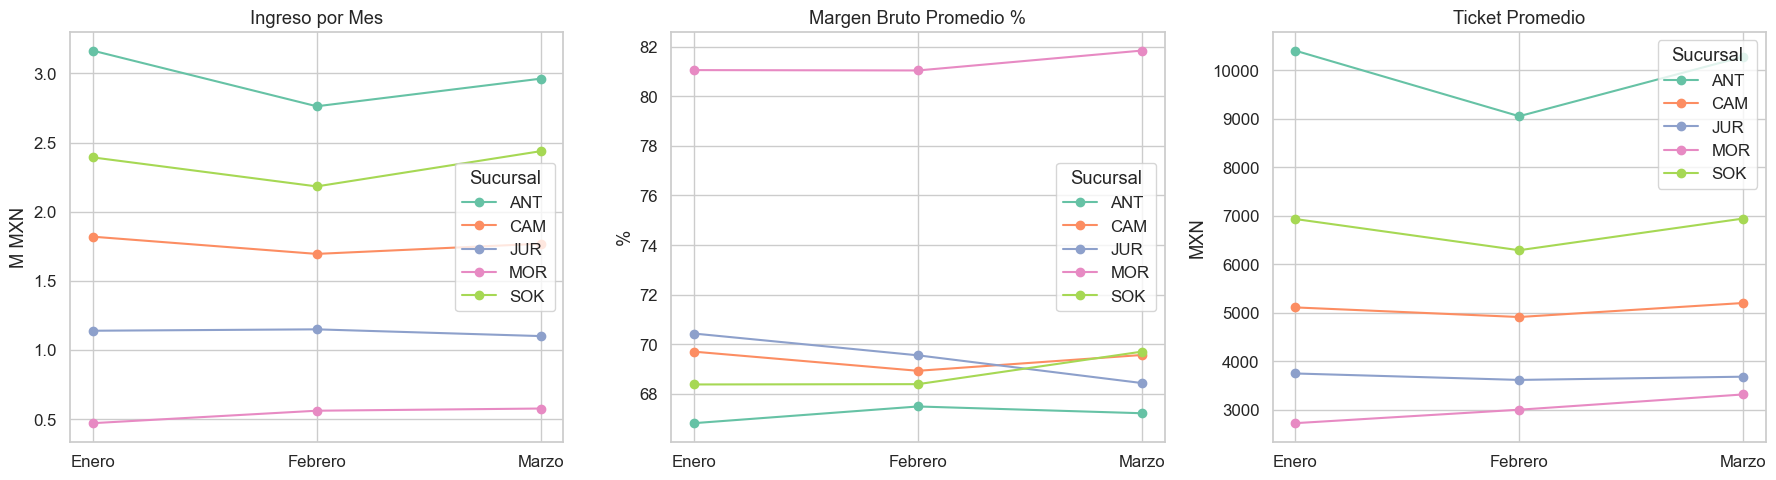


Ingreso mensual consolidado:
  ENERO 2026: $ 8,986,390.62 MXN  
  FEBRERO 2026: $ 8,349,195.51 MXN  (-7.1% vs ene)
  MARZO 2026: $ 8,844,724.52 MXN  (-1.6% vs ene)


In [14]:
# --- 2.4.2 Tendencia mensual por sucursal (líneas) ---
monthly_suc = bd.groupby(['MES','SUCURSAL']).agg(
    Ingreso=('SUBTOTAL','sum'),
    Margen=('MARGEN BRUTO','mean'),
    Ticket=('SUBTOTAL','mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sucursales = sorted(bd['SUCURSAL'].unique())
colors_s = dict(zip(sucursales, sns.color_palette('Set2', len(sucursales))))

for suc in sucursales:
    data = monthly_suc[monthly_suc['SUCURSAL'] == suc].set_index('MES').reindex(MES_ORDER)
    axes[0].plot(range(3), data['Ingreso'] / 1e6, marker='o', label=suc, color=colors_s[suc])
    axes[1].plot(range(3), data['Margen'] * 100, marker='o', label=suc, color=colors_s[suc])
    axes[2].plot(range(3), data['Ticket'], marker='o', label=suc, color=colors_s[suc])

for ax, title, ylabel in zip(axes,
    ['Ingreso por Mes', 'Margen Bruto Promedio %', 'Ticket Promedio'],
    ['M MXN', '%', 'MXN']):
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Enero','Febrero','Marzo'])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(title='Sucursal')

plt.tight_layout()
plt.show()

# Tabla resumen MoM
print("\nIngreso mensual consolidado:")
cons = bd.groupby('MES')['SUBTOTAL'].sum().reindex(MES_ORDER)
for i, mes in enumerate(MES_ORDER):
    delta = f"({(cons[mes]/cons[MES_ORDER[0]]-1)*100:+.1f}% vs ene)" if i > 0 else ""
    print(f"  {mes}: ${cons[mes]:>13,.2f} MXN  {delta}")

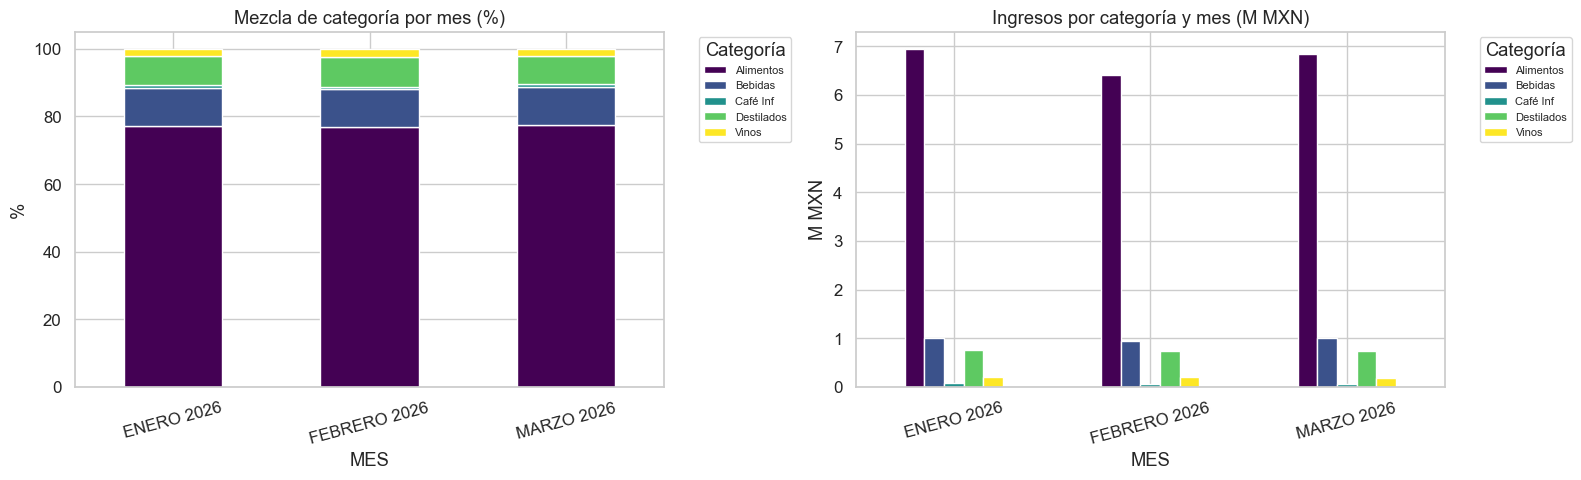

In [15]:
# --- 2.4.3 Evolución de mezcla de ventas por categoría ---
mix = bd.pivot_table(values='SUBTOTAL', index='MES', columns='SUBCATEGORÍA 1',
                      aggfunc='sum', fill_value=0).reindex(MES_ORDER)
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mix_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('Mezcla de categoría por mes (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Categoría', bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)

(mix / 1e6).plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Ingresos por categoría y mes (M MXN)')
axes[1].set_ylabel('M MXN')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Categoría', bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

---
## 3. Análisis de costos y márgenes

**Justificación:** El margen bruto es la métrica central de rentabilidad a nivel producto. Entender su distribución permite identificar productos que destruyen valor y oportunidades de optimización de precios/costos.

> **Nota:** A partir de aquí, todos los análisis usan `bd` filtrado (solo productos con ventas reales, sin los ~1,196 registros placeholder con SUBTOTAL=0).

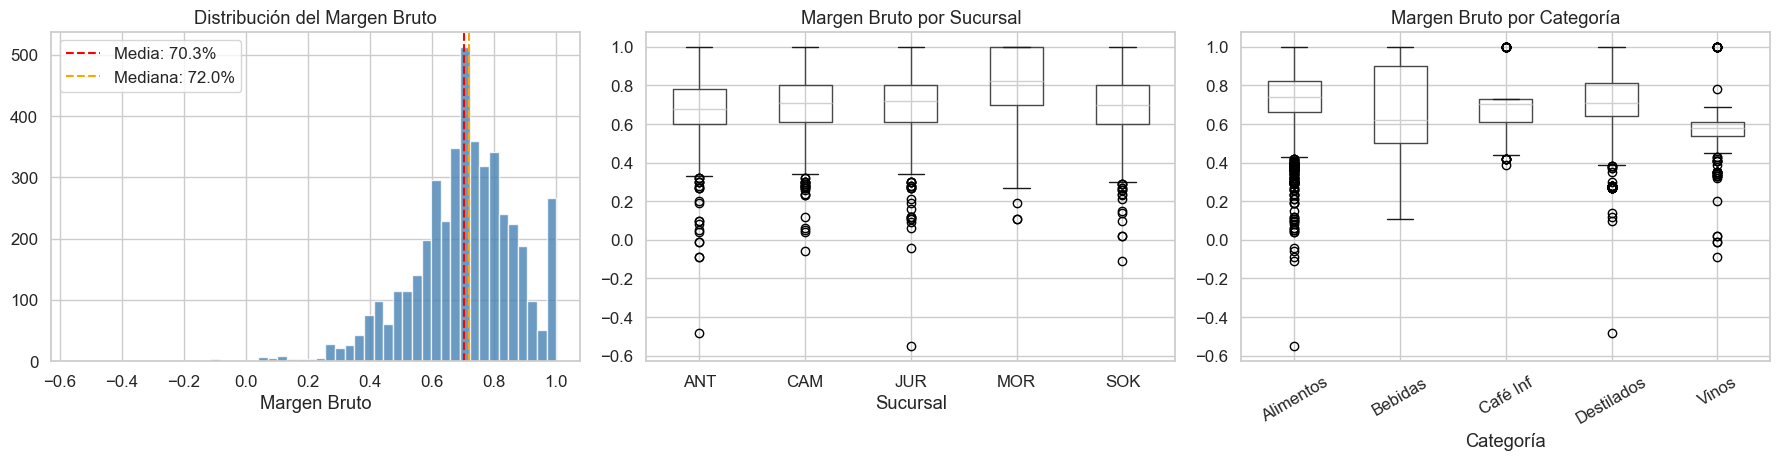

Margen bruto por sucursal:
           mean    50%    std     min     max
SUCURSAL                                     
ANT      67.18% 68.00% 16.35% -48.00% 100.00%
CAM      69.41% 71.00% 15.70%  -6.00% 100.00%
JUR      69.49% 72.00% 16.63% -55.00% 100.00%
MOR      81.30% 82.50% 18.08%  11.00% 100.00%
SOK      68.84% 70.00% 15.55% -11.00% 100.00%


In [16]:
# --- 3.1 Distribución del margen bruto ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma general
axes[0].hist(bd['MARGEN BRUTO'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(bd['MARGEN BRUTO'].mean(), color='red', linestyle='--', label=f"Media: {bd['MARGEN BRUTO'].mean():.1%}")
axes[0].axvline(bd['MARGEN BRUTO'].median(), color='orange', linestyle='--', label=f"Mediana: {bd['MARGEN BRUTO'].median():.1%}")
axes[0].set_title('Distribución del Margen Bruto')
axes[0].set_xlabel('Margen Bruto')
axes[0].legend()

# Boxplot por sucursal
bd.boxplot(column='MARGEN BRUTO', by='SUCURSAL', ax=axes[1])
axes[1].set_title('Margen Bruto por Sucursal')
axes[1].set_xlabel('Sucursal')
plt.suptitle('')

# Boxplot por categoría
bd.boxplot(column='MARGEN BRUTO', by='SUBCATEGORÍA 1', ax=axes[2])
axes[2].set_title('Margen Bruto por Categoría')
axes[2].set_xlabel('Categoría')
axes[2].tick_params(axis='x', rotation=30)
plt.suptitle('')

plt.tight_layout()
plt.show()

# Resumen estadístico
print("Margen bruto por sucursal:")
print(bd.groupby('SUCURSAL')['MARGEN BRUTO'].describe()[['mean', '50%', 'std', 'min', 'max']].to_string(float_format='{:.2%}'.format))

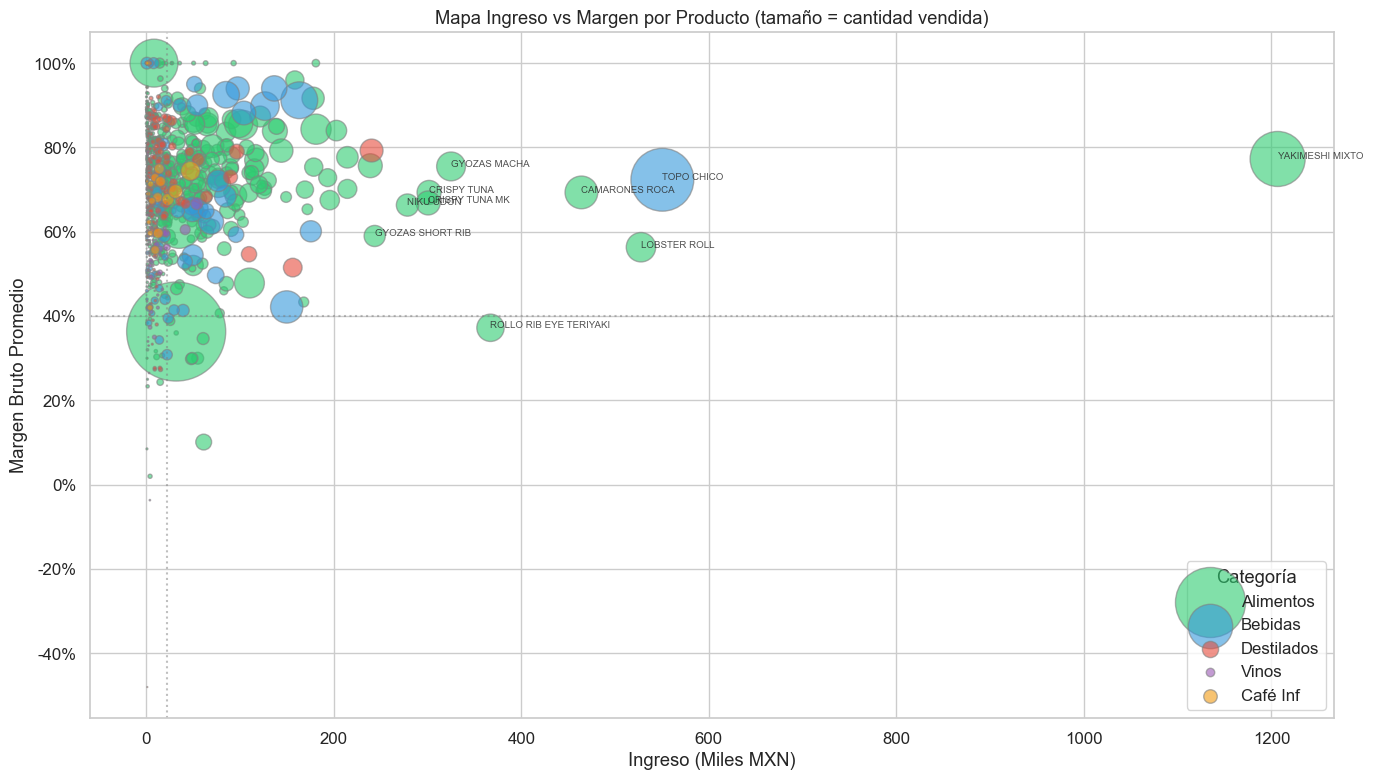

In [17]:
# --- 3.2 Scatter: Ingreso vs Margen por producto ---
prod_agg = bd.groupby('SUBCATEGORÍA 2').agg(
    Ingreso=('SUBTOTAL', 'sum'),
    Margen=('MARGEN BRUTO', 'mean'),
    Cantidad=('CANTIDAD', 'sum'),
    Categoria=('SUBCATEGORÍA 1', 'first'),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 8))
cat_colors = {'Alimentos': '#2ecc71', 'Bebidas': '#3498db', 'Destilados': '#e74c3c',
              'Vinos': '#9b59b6', 'Café Inf': '#f39c12'}

for cat, color in cat_colors.items():
    mask = prod_agg['Categoria'] == cat
    ax.scatter(prod_agg.loc[mask, 'Ingreso'] / 1000, prod_agg.loc[mask, 'Margen'],
               s=prod_agg.loc[mask, 'Cantidad'] / 5, alpha=0.6, label=cat, color=color, edgecolors='gray')

# Cuadrantes
ax.axhline(0.4, color='gray', linestyle=':', alpha=0.5)
ax.axvline(prod_agg['Ingreso'].quantile(0.75) / 1000, color='gray', linestyle=':', alpha=0.5)

# Etiquetar top productos
for _, row in prod_agg.nlargest(10, 'Ingreso').iterrows():
    ax.annotate(row['SUBCATEGORÍA 2'], (row['Ingreso']/1000, row['Margen']),
                fontsize=7, alpha=0.8, ha='left')

ax.set_xlabel('Ingreso (Miles MXN)')
ax.set_ylabel('Margen Bruto Promedio')
ax.set_title('Mapa Ingreso vs Margen por Producto (tamaño = cantidad vendida)')
ax.legend(title='Categoría')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

In [18]:
# --- 3.3 Productos con margen negativo o cero ---
neg_margin = bd[bd['UTILIDAD BRUTA'] < 0][['SUCURSAL', 'SUBCATEGORÍA 1', 'SUBCATEGORÍA 2',
                                             'CANTIDAD', 'SUBTOTAL', 'COSTO TOTAL SIN IVA',
                                             'UTILIDAD BRUTA', 'MARGEN BRUTO']].sort_values('UTILIDAD BRUTA')

print(f"Productos con utilidad bruta negativa: {len(neg_margin)}")
print(f"Pérdida total por margen negativo: ${neg_margin['UTILIDAD BRUTA'].sum():,.2f} MXN\n")
neg_margin

Productos con utilidad bruta negativa: 9
Pérdida total por margen negativo: $-869.70 MXN



,SUCURSAL,SUBCATEGORÍA 1,SUBCATEGORÍA 2,CANTIDAD,SUBTOTAL,COSTO TOTAL SIN IVA,UTILIDAD BRUTA,MARGEN BRUTO
6159,ANT,Destilados,HAKKAISAN 300 ML,2,1068.97,1579.98,-511.01,-0.48
6132,ANT,Vinos,"KENDALL, CHARDONNAY",2,1451.29,1581.40,-130.11,-0.09
6166,ANT,Alimentos,PULPO SH,11,862.50,936.13,-73.63,-0.09
7264,JUR,Alimentos,TEMPURA ATUN MK,5,133.62,207.22,-73.60,-0.55
5078,SOK,Alimentos,YAKIMESHI SHORT RIB,4,275.86,306.18,-30.32,-0.11
7197,JUR,Alimentos,CALIF HUACHINANGO MK,14,689.66,715.61,-25.95,-0.04
2886,ANT,Vinos,"KENDALL, CHARDONNAY",2,1568.97,1581.40,-12.43,-0.01
3517,CAM,Alimentos,TEMPURA PULPO MK,2,103.45,109.88,-6.43,-0.06
264,ANT,Vinos,"KENDALL, CHARDONNAY",1,784.48,790.70,-6.22,-0.01


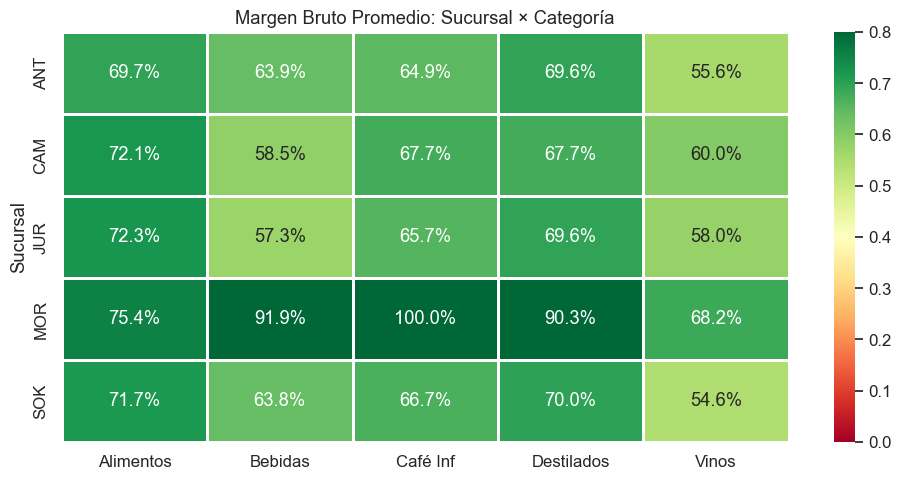

In [19]:
# --- 3.4 Heatmap: Margen bruto promedio por Sucursal × Categoría ---
margin_pivot = bd.pivot_table(values='MARGEN BRUTO', index='SUCURSAL',
                               columns='SUBCATEGORÍA 1', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(margin_pivot, annot=True, fmt='.1%', cmap='RdYlGn', center=0.4,
            linewidths=1, ax=ax, vmin=0, vmax=0.8)
ax.set_title('Margen Bruto Promedio: Sucursal × Categoría')
ax.set_ylabel('Sucursal')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

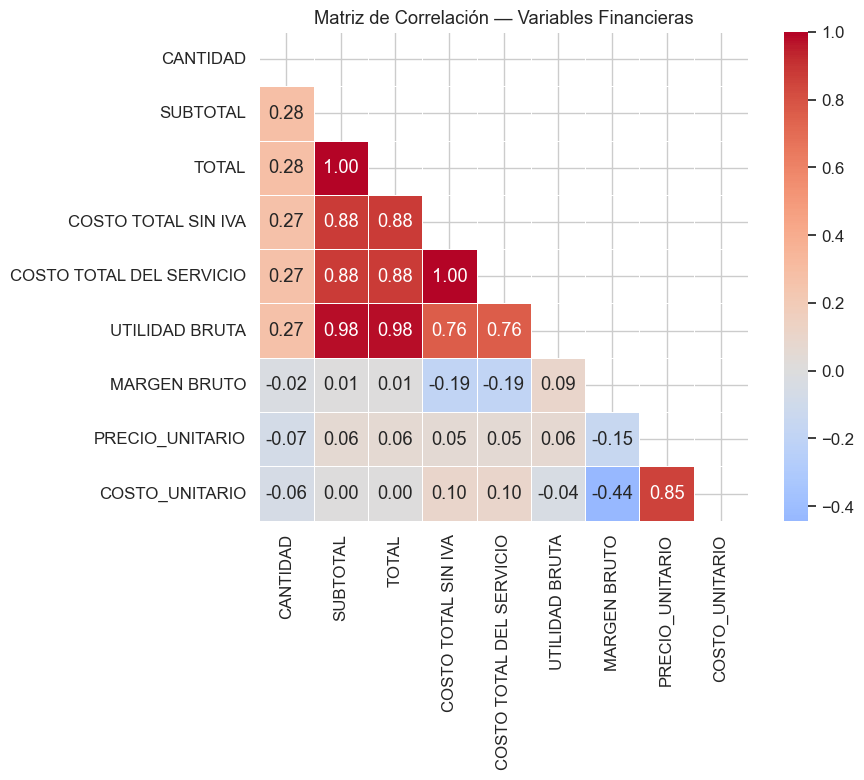

In [20]:
# --- 3.5 Correlación entre variables financieras clave ---
fin_cols = ['CANTIDAD', 'SUBTOTAL', 'TOTAL', 'COSTO TOTAL SIN IVA',
            'COSTO TOTAL DEL SERVICIO', 'UTILIDAD BRUTA', 'MARGEN BRUTO',
            'PRECIO_UNITARIO', 'COSTO_UNITARIO']

fig, ax = plt.subplots(figsize=(10, 8))
corr = bd[fin_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlación — Variables Financieras')
plt.tight_layout()
plt.show()

---
## 4. Análisis de gastos operativos

**Justificación:** Los gastos operativos son el segundo gran componente del estado de resultados después del costo de ventas. Su distribución por categoría y sucursal revela dónde se concentra la estructura de costos fijos y variables del negocio.

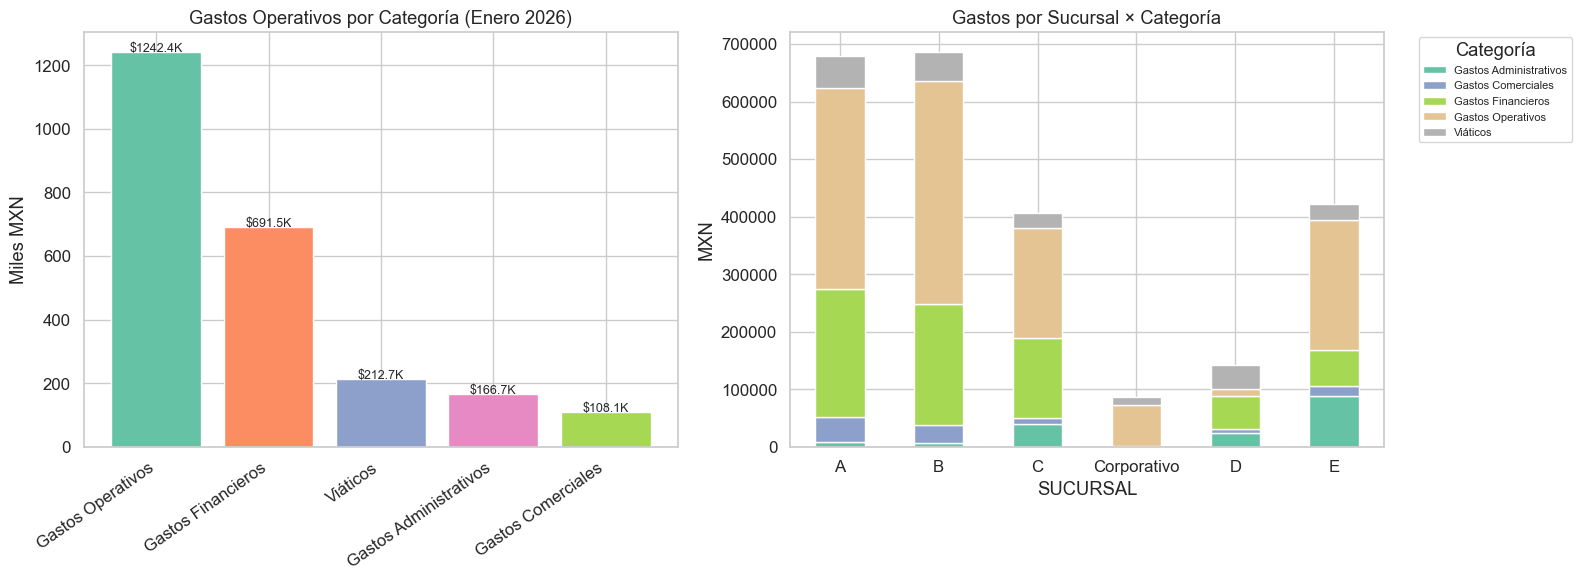


Gasto total enero: $2,421,373.12 MXN


In [21]:
# --- 4.1 Gastos por categoría ---
gastos_cat = gastos.groupby('CATEGORÍA GASTO')['SUBTOTAL'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot
bars = axes[0].bar(range(len(gastos_cat)), gastos_cat.values / 1000, color=sns.color_palette('Set2'))
axes[0].set_xticks(range(len(gastos_cat)))
axes[0].set_xticklabels(gastos_cat.index, rotation=35, ha='right')
axes[0].set_ylabel('Miles MXN')
axes[0].set_title('Gastos Operativos por Categoría (Enero 2026)')
for bar, val in zip(bars, gastos_cat.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'${val/1000:.1f}K', ha='center', fontsize=9)

# Treemap-style: gastos por categoría × sucursal
gastos_suc = gastos.groupby(['SUCURSAL', 'CATEGORÍA GASTO'])['SUBTOTAL'].sum().reset_index()
gastos_pivot = gastos_suc.pivot_table(values='SUBTOTAL', index='SUCURSAL',
                                       columns='CATEGORÍA GASTO', aggfunc='sum', fill_value=0)
gastos_pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Gastos por Sucursal × Categoría')
axes[1].set_ylabel('MXN')
axes[1].legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"\nGasto total enero: ${gastos['SUBTOTAL'].sum():,.2f} MXN")

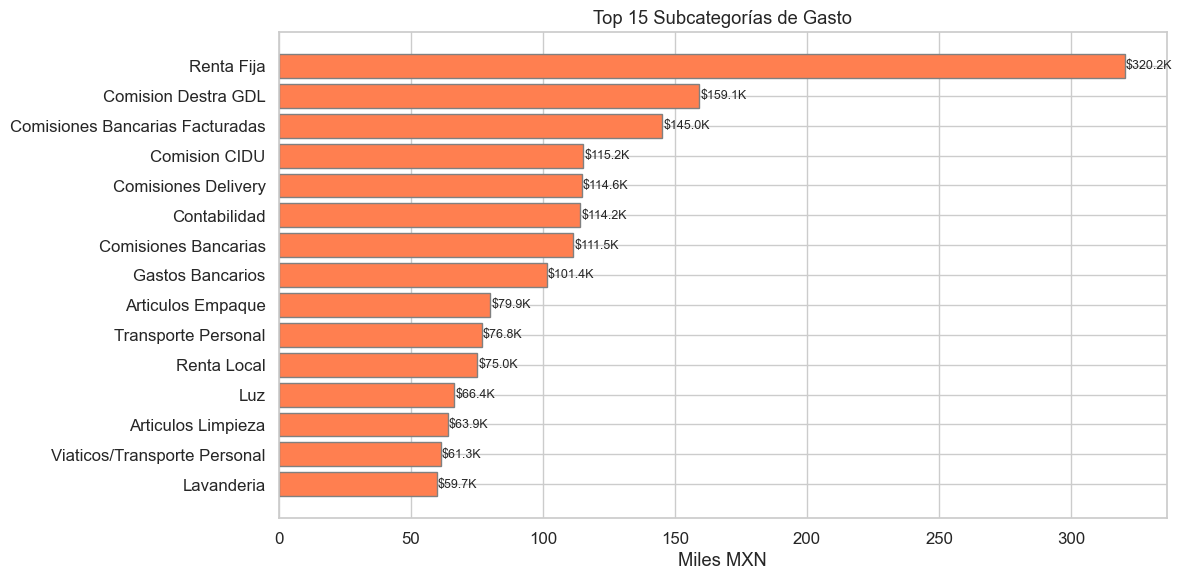

In [22]:
# --- 4.2 Top subcategorías de gasto ---
gastos_sub = gastos.groupby('SUBCATEGORÍA')['SUBTOTAL'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
gastos_sub_sorted = gastos_sub.sort_values()
ax.barh(gastos_sub_sorted.index, gastos_sub_sorted.values / 1000, color='coral', edgecolor='gray')
ax.set_xlabel('Miles MXN')
ax.set_title('Top 15 Subcategorías de Gasto')
for i, val in enumerate(gastos_sub_sorted.values):
    ax.text(val/1000 + 0.5, i, f'${val/1000:.1f}K', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Análisis de nómina

**Justificación:** El costo laboral suele ser el gasto más significativo en restaurantes. Analizar su composición por sucursal y concepto permite identificar diferencias en la estructura operativa.

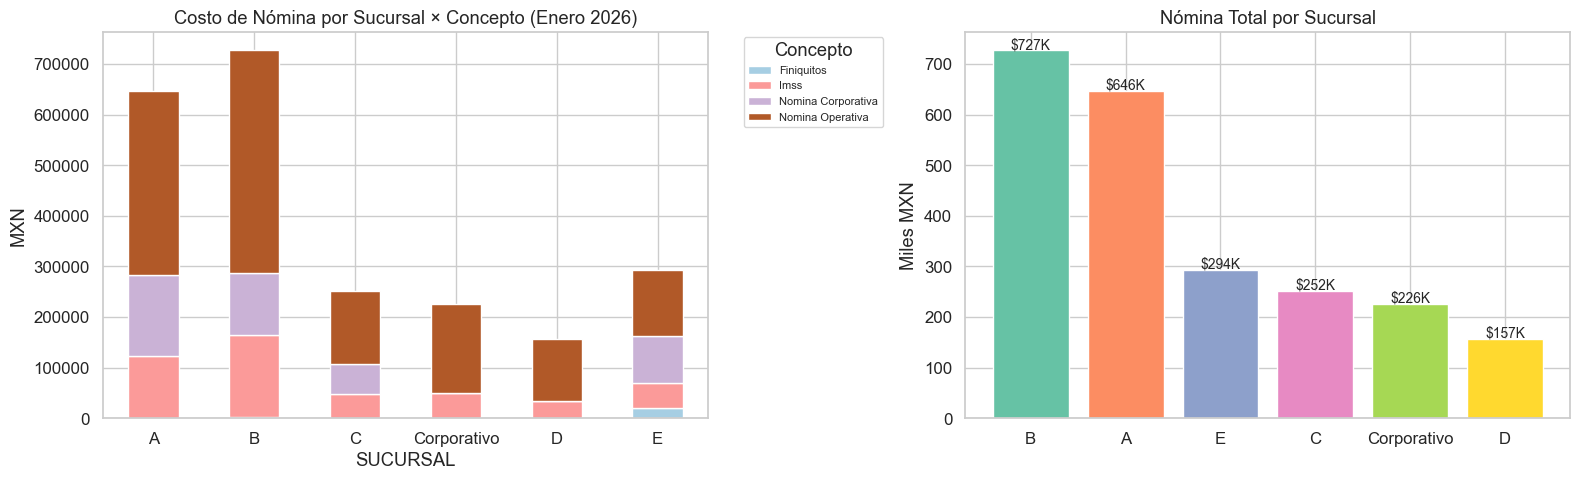

Nómina total enero: $2,301,832.96 MXN

Desglose por concepto:
CONCEPTO_NÓMINA
Nomina Operativa     $1,377,390.83
Imss                   $467,001.16
Nomina Corporativa     $434,466.64
Finiquitos              $22,974.34


In [23]:
# --- 5.1 Nómina por sucursal y concepto ---
nom_pivot = nomina.pivot_table(values='SUBTOTAL', index='SUCURSAL', columns='CONCEPTO_NÓMINA',
                                aggfunc='sum', fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar
nom_pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='Paired')
axes[0].set_title('Costo de Nómina por Sucursal × Concepto (Enero 2026)')
axes[0].set_ylabel('MXN')
axes[0].legend(title='Concepto', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# Total por sucursal
nom_total = nomina.groupby('SUCURSAL')['SUBTOTAL'].sum().sort_values(ascending=False)
bars = axes[1].bar(nom_total.index, nom_total.values / 1000, color=sns.color_palette('Set2'))
axes[1].set_title('Nómina Total por Sucursal')
axes[1].set_ylabel('Miles MXN')
for bar, val in zip(bars, nom_total.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'${val/1000:.0f}K', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Nómina total enero: ${nomina['SUBTOTAL'].sum():,.2f} MXN")
print(f"\nDesglose por concepto:")
print(nomina.groupby('CONCEPTO_NÓMINA')['SUBTOTAL'].sum().sort_values(ascending=False).to_string(float_format='${:,.2f}'.format))

---
## 6. Estado de resultados simplificado por sucursal

**Justificación:** Integrar ingresos, costos de venta, gastos operativos y nómina en una sola vista
permite evaluar la rentabilidad real de cada sucursal.

> ⚠️ **Limitación:** Gastos operativos y nómina provienen del xlsx y cubren **solo enero 2026**.
> El ER se construye con ingresos de enero únicamente para mantener consistencia en el período.

In [24]:
# --- 6.1 Construir ER simplificado (enero 2026) ---
# Filtrar BD solo a enero
bd_enero = bd[bd['MES'] == 'ENERO 2026'].copy()

ingresos       = bd_enero.groupby('SUCURSAL')['SUBTOTAL'].sum()
costos_venta   = bd_enero.groupby('SUCURSAL')['COSTO TOTAL SIN IVA'].sum()
utilidad_bruta = bd_enero.groupby('SUCURSAL')['UTILIDAD BRUTA'].sum()

# gastos y nómina ya usan códigos ANT/SOK/JUR/MOR/CAM tras la limpieza en sección 1.3
gastos_suc_total = gastos[gastos['SUCURSAL'].isin(['ANT','SOK','JUR','MOR','CAM'])].groupby('SUCURSAL')['SUBTOTAL'].sum()
nomina_suc_total = nomina.groupby('SUCURSAL')['SUBTOTAL'].sum()

er = pd.DataFrame({
    'Ingresos': ingresos,
    'Costo de Ventas': costos_venta,
    'Utilidad Bruta': utilidad_bruta,
    'Gastos Operativos': gastos_suc_total,
    'Nómina': nomina_suc_total,
}).fillna(0)
er.index.name = 'Sucursal'

er['EBITDA Aprox']    = er['Utilidad Bruta'] - er['Gastos Operativos'] - er['Nómina']
er['Margen Bruto %']  = er['Utilidad Bruta'] / er['Ingresos']
er['Margen EBITDA %'] = er['EBITDA Aprox'] / er['Ingresos']

er.loc['TOTAL'] = er.sum()
er.loc['TOTAL', 'Margen Bruto %']  = er.loc['TOTAL', 'Utilidad Bruta'] / er.loc['TOTAL', 'Ingresos']
er.loc['TOTAL', 'Margen EBITDA %'] = er.loc['TOTAL', 'EBITDA Aprox']  / er.loc['TOTAL', 'Ingresos']

print("Estado de Resultados Simplificado — Enero 2026 (MXN)")
print("=" * 100)
display_cols = ['Ingresos','Costo de Ventas','Utilidad Bruta','Gastos Operativos',
                'Nómina','EBITDA Aprox','Margen Bruto %','Margen EBITDA %']
print(er[display_cols].to_string(float_format='${:,.0f}'.format))

Estado de Resultados Simplificado — Enero 2026 (MXN)
              Ingresos  Costo de Ventas  Utilidad Bruta  Gastos Operativos     Nómina  EBITDA Aprox  Margen Bruto %  Margen EBITDA %
Sucursal                                                                                                                            
A           $3,164,779         $968,227      $2,196,552           $678,519   $646,360      $871,673              $1               $0
B           $2,392,551         $752,755      $1,639,795           $686,704   $726,891      $226,200              $1               $0
C           $1,139,072         $309,557        $829,515           $405,974   $251,993      $171,548              $1               $0
Corporativo         $0               $0              $0                 $0   $225,866     $-225,866             NaN            $-inf
D             $470,759         $131,077        $339,682           $142,173   $157,106       $40,404              $1               $0
E           $1,8

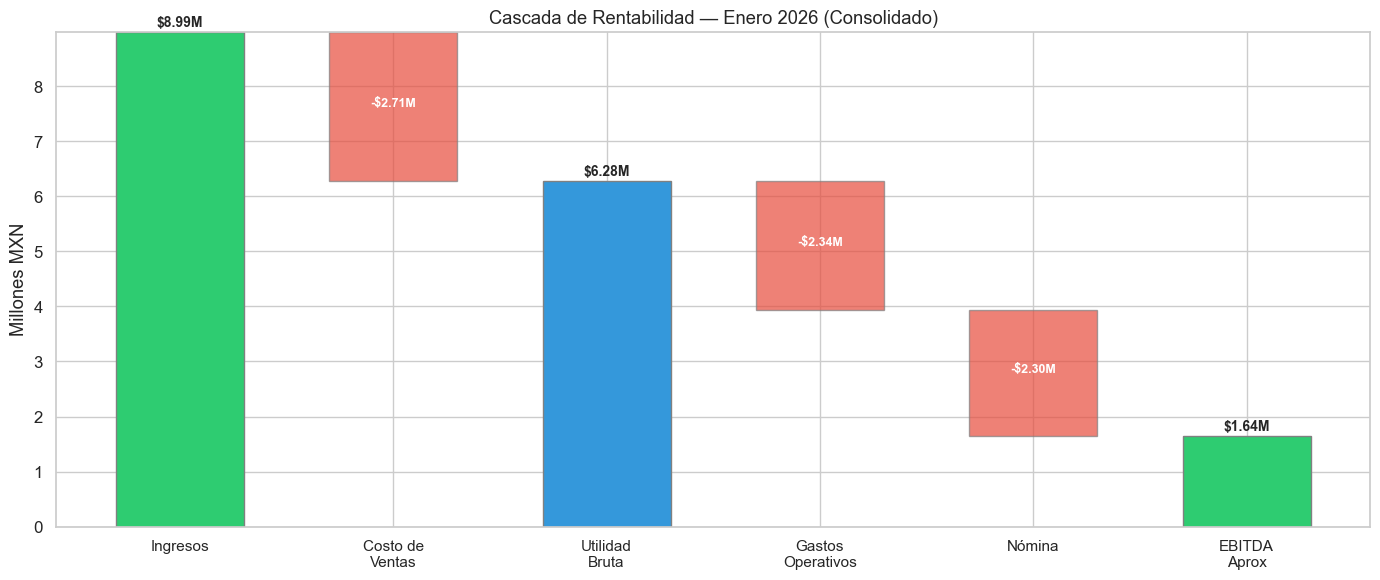

In [25]:
# --- 6.2 Waterfall de rentabilidad consolidada ---
total = er.loc['TOTAL']
categories = ['Ingresos', 'Costo de\nVentas', 'Utilidad\nBruta', 'Gastos\nOperativos', 'Nómina', 'EBITDA\nAprox']
values = [total['Ingresos'], -total['Costo de Ventas'], total['Utilidad Bruta'],
          -total['Gastos Operativos'], -total['Nómina'], total['EBITDA Aprox']]

fig, ax = plt.subplots(figsize=(14, 6))
colors_wf = ['#2ecc71', '#e74c3c', '#3498db', '#e74c3c', '#e74c3c', '#2ecc71' if values[-1] > 0 else '#e74c3c']

# Simple waterfall
cumulative = 0
for i, (cat, val, col) in enumerate(zip(categories, values, colors_wf)):
    if i in [0, 2, 5]:  # Totals
        ax.bar(i, val/1e6, color=col, edgecolor='gray', width=0.6)
        ax.text(i, val/1e6 + 0.1, f'${val/1e6:.2f}M', ha='center', fontsize=10, fontweight='bold')
    else:  # Decrements
        bottom = cumulative
        ax.bar(i, val/1e6, bottom=bottom/1e6, color=col, edgecolor='gray', width=0.6, alpha=0.7)
        ax.text(i, (bottom + val/2)/1e6, f'-${abs(val)/1e6:.2f}M', ha='center', fontsize=9, color='white', fontweight='bold')
    if i not in [2, 5]:
        cumulative += val

ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Millones MXN')
ax.set_title('Cascada de Rentabilidad — Enero 2026 (Consolidado)')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

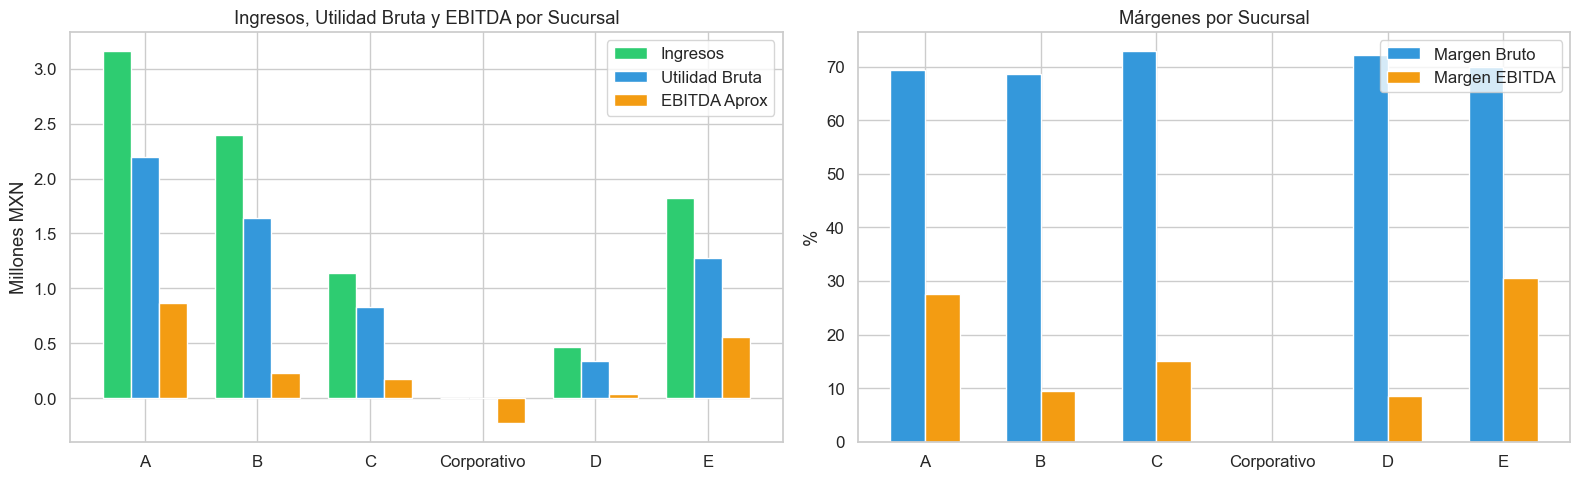

In [26]:
# --- 6.3 Comparativa de rentabilidad por sucursal ---
er_suc = er.drop('TOTAL')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot agrupado
x = np.arange(len(er_suc))
width = 0.25
axes[0].bar(x - width, er_suc['Ingresos']/1e6, width, label='Ingresos', color='#2ecc71')
axes[0].bar(x, er_suc['Utilidad Bruta']/1e6, width, label='Utilidad Bruta', color='#3498db')
axes[0].bar(x + width, er_suc['EBITDA Aprox']/1e6, width, label='EBITDA Aprox', color='#f39c12')
axes[0].set_xticks(x)
axes[0].set_xticklabels(er_suc.index)
axes[0].set_ylabel('Millones MXN')
axes[0].set_title('Ingresos, Utilidad Bruta y EBITDA por Sucursal')
axes[0].legend()

# Márgenes
axes[1].bar(x - 0.15, er_suc['Margen Bruto %'] * 100, 0.3, label='Margen Bruto', color='#3498db')
axes[1].bar(x + 0.15, er_suc['Margen EBITDA %'] * 100, 0.3, label='Margen EBITDA', color='#f39c12')
axes[1].set_xticks(x)
axes[1].set_xticklabels(er_suc.index)
axes[1].set_ylabel('%')
axes[1].set_title('Márgenes por Sucursal')
axes[1].legend()
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

---
## 7. Distribución de precios y volúmenes

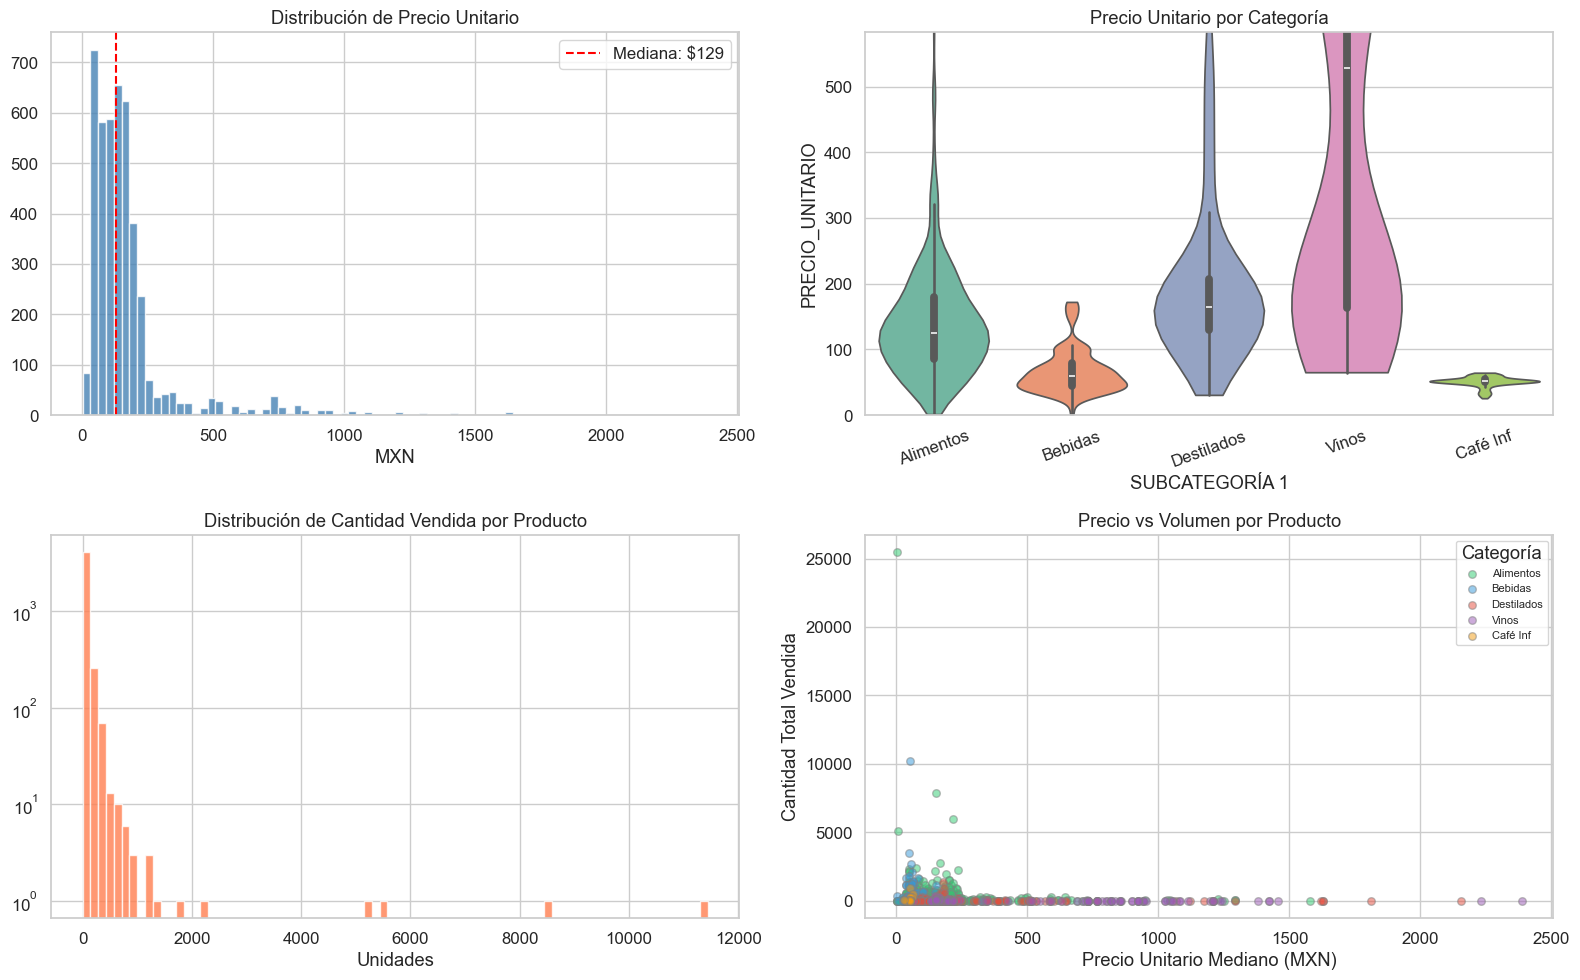

In [27]:
# --- 7.1 Distribución de precios unitarios y cantidades ---
bd_pos = bd[bd['CANTIDAD'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Precio unitario - histograma
axes[0, 0].hist(bd_pos['PRECIO_UNITARIO'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribución de Precio Unitario')
axes[0, 0].set_xlabel('MXN')
axes[0, 0].axvline(bd_pos['PRECIO_UNITARIO'].median(), color='red', linestyle='--',
                     label=f"Mediana: ${bd_pos['PRECIO_UNITARIO'].median():.0f}")
axes[0, 0].legend()

# Precio unitario por categoría - violinplot
sns.violinplot(data=bd_pos, x='SUBCATEGORÍA 1', y='PRECIO_UNITARIO', ax=axes[0, 1],
               palette='Set2', cut=0)
axes[0, 1].set_title('Precio Unitario por Categoría')
axes[0, 1].set_ylim(0, bd_pos['PRECIO_UNITARIO'].quantile(0.95))
axes[0, 1].tick_params(axis='x', rotation=20)

# Cantidad vendida - log scale
axes[1, 0].hist(bd_pos['CANTIDAD'], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Distribución de Cantidad Vendida por Producto')
axes[1, 0].set_xlabel('Unidades')
axes[1, 0].set_yscale('log')

# Scatter: Precio vs Cantidad (a nivel producto agregado)
prod = bd_pos.groupby('SUBCATEGORÍA 2').agg(
    Precio_Med=('PRECIO_UNITARIO', 'median'),
    Cantidad_Total=('CANTIDAD', 'sum'),
    Categoria=('SUBCATEGORÍA 1', 'first'),
).reset_index()
for cat, col in cat_colors.items():
    m = prod['Categoria'] == cat
    axes[1, 1].scatter(prod.loc[m, 'Precio_Med'], prod.loc[m, 'Cantidad_Total'],
                        alpha=0.5, color=col, label=cat, edgecolors='gray', s=30)
axes[1, 1].set_xlabel('Precio Unitario Mediano (MXN)')
axes[1, 1].set_ylabel('Cantidad Total Vendida')
axes[1, 1].set_title('Precio vs Volumen por Producto')
axes[1, 1].legend(title='Categoría', fontsize=8)

plt.tight_layout()
plt.show()

---
## 8. Análisis de la categoría de menú (CATEGORÍA MENÚ)

**Justificación:** Esta variable agrupa los productos por su posición en el menú (MAKIS, NIGIRI, BEBIDAS, DESTILADOS, etc.), lo cual es clave para entender la composición de ventas desde la perspectiva operativa del restaurante.

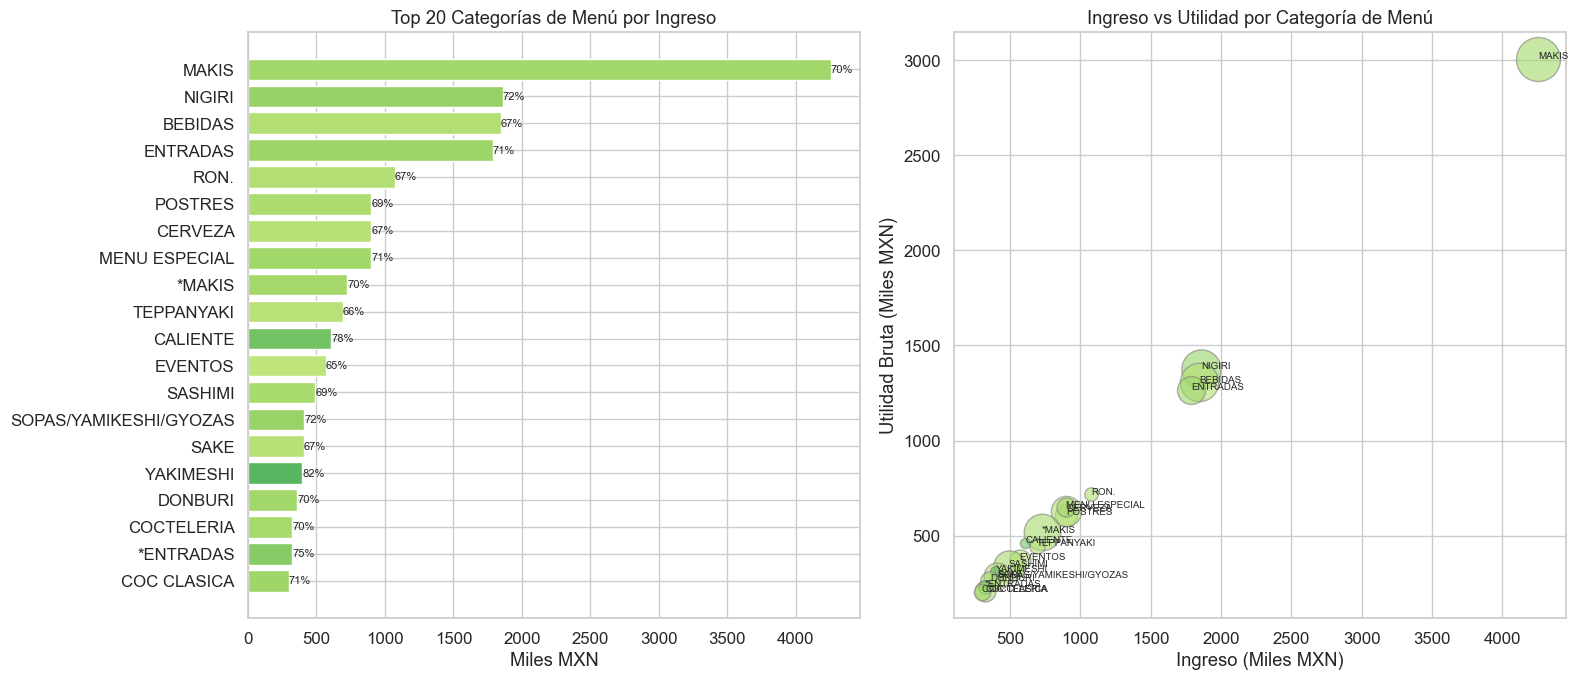

In [28]:
# --- 8.1 Top categorías de menú por ingreso y margen ---
menu_agg = bd.groupby('CATEGORÍA MENÚ').agg(
    Transacciones=('SUBTOTAL', 'count'),
    Ingreso=('SUBTOTAL', 'sum'),
    Margen_Prom=('MARGEN BRUTO', 'mean'),
    Utilidad=('UTILIDAD BRUTA', 'sum'),
).sort_values('Ingreso', ascending=False)

top_menu = menu_agg.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Ingreso por categoría de menú
top_sorted = top_menu.sort_values('Ingreso')
bars = axes[0].barh(top_sorted.index, top_sorted['Ingreso'] / 1000,
                     color=[plt.cm.RdYlGn(m) for m in top_sorted['Margen_Prom']])
axes[0].set_xlabel('Miles MXN')
axes[0].set_title('Top 20 Categorías de Menú por Ingreso')
for i, (ing, marg) in enumerate(zip(top_sorted['Ingreso'], top_sorted['Margen_Prom'])):
    axes[0].text(ing/1000 + 1, i, f'{marg:.0%}', va='center', fontsize=8)

# Utilidad vs Ingreso (bubble)
for _, row in top_menu.iterrows():
    axes[1].scatter(row['Ingreso']/1000, row['Utilidad']/1000,
                     s=row['Transacciones']*3, alpha=0.6,
                     color=plt.cm.RdYlGn(row['Margen_Prom']), edgecolors='gray')
    axes[1].annotate(row.name, (row['Ingreso']/1000, row['Utilidad']/1000), fontsize=7)

axes[1].set_xlabel('Ingreso (Miles MXN)')
axes[1].set_ylabel('Utilidad Bruta (Miles MXN)')
axes[1].set_title('Ingreso vs Utilidad por Categoría de Menú')

plt.tight_layout()
plt.show()

---
## 9. Insights clave (Q1 2026)

### Datos
- **Dataset actualizado:** CSV cubre enero–marzo 2026 (~8,100 registros, ~4,400 con venta real).
- Sucursales con nombre real: **ANT** (Antea), **SOK** (Soke), **JUR** (Jur), **MOR** (Mor), **CAM** (Cam).
- Gastos operativos y nómina solo disponibles para **enero 2026** (xlsx).

### Ingresos Q1 2026
- **ANT lidera** con el mayor volumen en los tres meses (~$2.7–3.2M/mes). **MOR es la más débil** (~$470–577K/mes).
- **Ingresos totales Q1:** ~$26.2M MXN (ene $9.0M + feb $8.3M + mar $8.8M).
- Leve caída en febrero vs enero (~-7%), recuperación parcial en marzo (~-1.6% vs ene).
- **Alimentos ≈ 77%** del mix; Bebidas ~11%, Destilados ~8%. Mezcla estable los tres meses.

### Márgenes Q1 2026
- Margen bruto promedio mejoró levemente mes a mes: **ene 69.9% → feb 70.2% → mar 71.3%**.
- **Destilados y Vinos** siguen con márgenes ~20–30% por debajo de Alimentos/Bebidas — oportunidad de repricing.
- Productos con utilidad negativa son principalmente cortesías sin ingreso (SUBTOTAL=0).

### Tendencias temporales
- **MOR y CAM** muestran crecimiento en ingresos de enero a marzo; **ANT** con leve contracción.
- El ticket promedio es estable entre meses, sin señales de cambio de precio.

### Estado de resultados (enero 2026)
- **EBITDA consolidado enero:** ~$1.6M MXN (margen ~18%).
- Costo laboral (nómina) + gastos operativos consumen ~$4.6M de $6.3M de utilidad bruta.

### Accionables
1. **MOR**: crecimiento positivo pero base baja — investigar palancas de ticket.
2. **Destilados/Vinos**: renegociar costos o ajustar precios para alinear margen con Alimentos.
3. **Caída de febrero**: ¿estacionalidad o evento puntual? Monitorear con datos de abril.
4. **MAKIS + Alimentos calientes**: categorías estrella — proteger y potenciar.
5. **Incorporar gastos/nómina de febrero y marzo** para ER completo de Q1.